In [2]:
from imports import *

In [54]:
h

array([ 10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        10.,  10.,  10.,  10.,  10., 510., 510., 510., 510., 510., 510.,
       510., 510.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        10.,  10.,  10.,  10.,  10.,  10.,  10.])

Text(0.5, 0.6, 'Observed gravity')

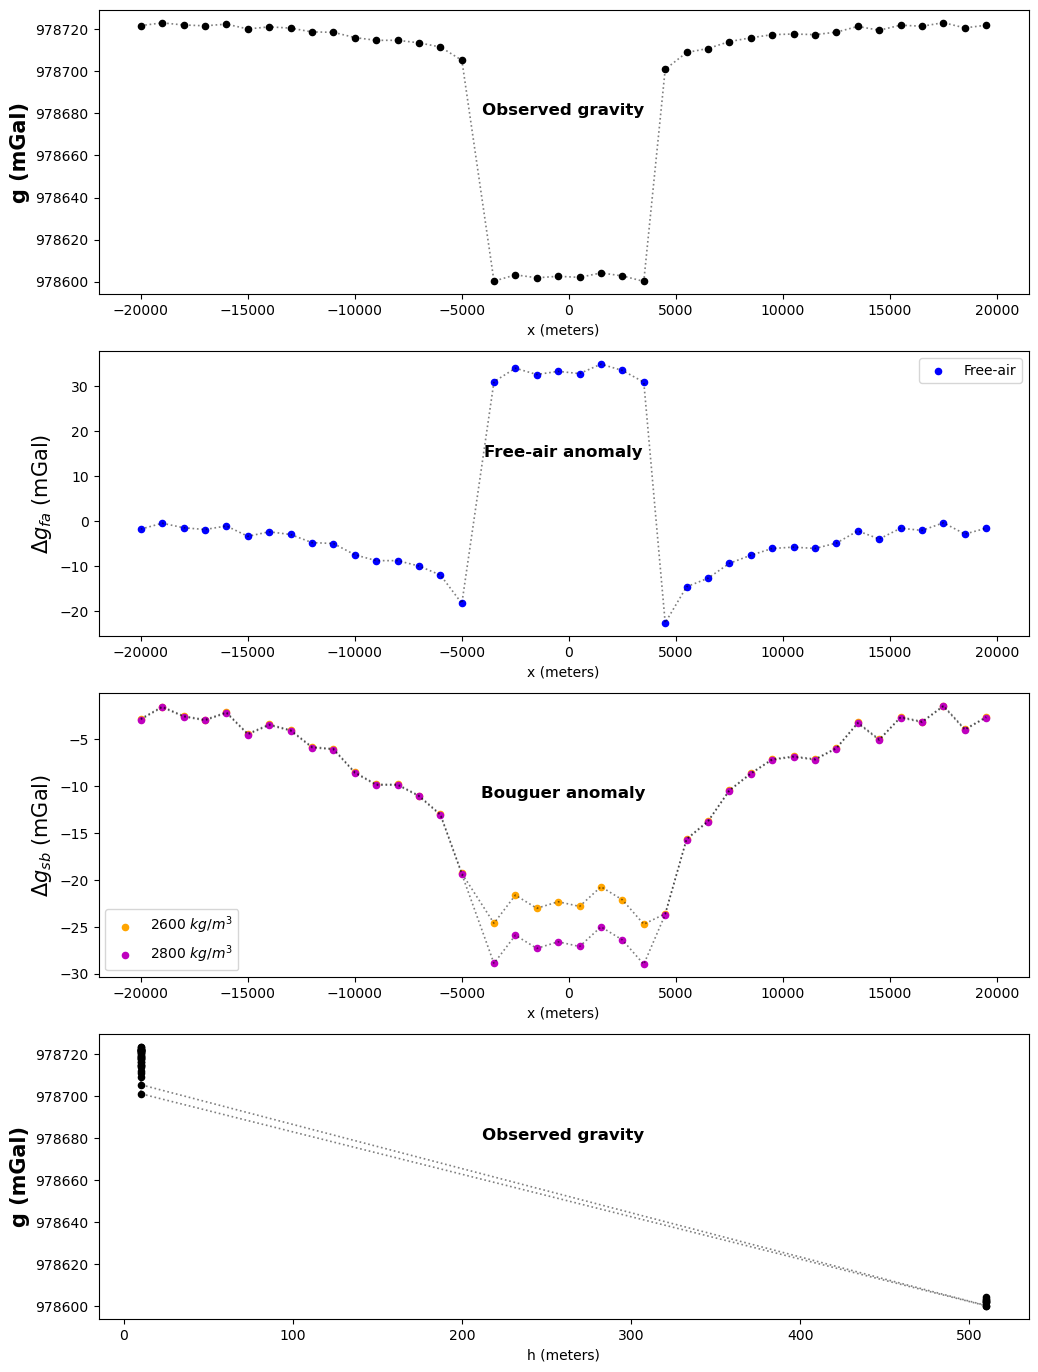

In [73]:
wgs84 = lambda lat:(9.7803267714)*((1+0.00193185138639*(np.sin(np.deg2rad(lat))**2))/ ((1-0.00669437999013*(np.sin(np.deg2rad(lat))**2))**0.5))
lat=21.5
g0=wgs84(lat)
G = 6.67430e-11

gsb = lambda rho,h: (2*np.pi*G*rho*(h))
# gsb = lambda rho,h:(0.1119e-5)*h
fa = lambda h: ((-0.3086e-5)*(h))


free_air_corrected = lambda g,h: (g/1e5)-fa(h)-g0
bouguer_corrected = lambda g,h,rho: (g/1e5)-(fa(h))-gsb(rho,h)-g0
data=np.loadtxt('/Users/charlesh/Downloads/data.hw6.txt')
x,h,g = data.T
fig,axes = plt.subplots(nrows=4,ncols=1,figsize=(12,17))
ax=axes[0]

unit_scale = 1/1e5
acc_to_mgal = 1e5
dotscale=20
ax.plot(x,g,linestyle=':',linewidth=1.2,color='k',alpha=0.5)
ax.scatter(x,g,color='k',s=dotscale)
ax.set_xlabel('x (meters)')
ax.set_ylabel('g (mGal)',fontweight='bold',fontsize=15)
ax.set_title('Observed gravity',y=0.6,fontweight='bold')
ax=axes[1]
# ax.plot(x,free_air_corrected(g,h),linestyle=':',linewidth=1.2,label=None,color='blue')
ax.scatter(x,free_air_corrected(g,h)*acc_to_mgal,label='Free-air',color='blue',s=dotscale)
ax.plot(x,free_air_corrected(g,h)*acc_to_mgal,linestyle=':',linewidth=1.2,color='k',alpha=0.5)
ax.legend()
ax.set_xlabel('x (meters)')
ax.set_ylabel('$\Delta g_{fa}$ (mGal)',fontsize=15)
ax.set_title('Free-air anomaly',y=0.6,fontweight='bold')


rho = 2600
ax=axes[2]
# ax.plot(x,free_air_corrected(g,h),linestyle=':',linewidth=1.2,label=None,color='blue')
[ax.plot(x,bouguer_corrected(g,h,rho)*acc_to_mgal,linestyle=':',linewidth=1.2,color='k',alpha=0.5) for ri,rho in enumerate([2600,2800])]
[ax.scatter(x,bouguer_corrected(g,h,rho)*acc_to_mgal,label=f'{str(rho)} $kg/m^{3}$',color=['orange','m'][ri],s=dotscale) for ri,rho in enumerate([2600,2800])]
ax.legend()
ax.set_xlabel('x (meters)')
ax.set_ylabel('$\Delta g_{sb}$ (mGal)',fontsize=15)
ax.set_title('Bouguer anomaly',y=0.6,fontweight='bold')


ax=axes[3]
ax.plot(h,g,linestyle=':',linewidth=1.2,color='k',alpha=0.5)
ax.scatter(h,g,s=dotscale,color='k')
ax.set_xlabel('h (meters)')
ax.set_ylabel('g (mGal)',fontweight='bold',fontsize=15)
ax.set_title('Observed gravity',y=0.6,fontweight='bold')

